# HTRU2 Pulsar Candidate Classification
## Machine Learning II – Unsupervised Learning Capstone

**Dataset:** HTRU2 – UCI Machine Learning Repository   
**Algorithms:** K-Means | Hierarchical Clustering | DBSCAN | PCA  
**Date:** May 2026

## 1. Introduction

The HTRU2 dataset contains pulsar candidate data collected during the High Time Resolution Universe Survey. 
Pulsars are rare types of neutron stars that produce detectable radio emissions. 
Identifying real pulsars from radio frequency interference is a key challenge in astrophysics.

This project applies **unsupervised learning** techniques to discover natural groupings 
within the data using:
- **K-Means Clustering**
- **Hierarchical (Agglomerative) Clustering**
- **DBSCAN**
- **PCA** for dimensionality reduction and visualisation

### 1.1 Problem Statement
Manual identification of pulsar candidates is slow and expensive. 
An automated clustering pipeline can reveal hidden structure in the data 
and assist astronomers in prioritising candidates for follow-up observation.

### 1.2 Dataset Justification
- 17,898 instances with 8 continuous numeric features 
- Ground truth labels available for external metric evaluation (ARI/NMI) 
- No missing values 
- Features are all numeric — ideal for distance-based clustering 

In [1]:
# SECTION 2: Import Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluation Metrics - Internal
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

# Evaluation Metrics - External
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Nearest Neighbours (for DBSCAN k-distance graph)
from sklearn.neighbors import NearestNeighbors

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

print(" All libraries imported successfully")

 All libraries imported successfully


In [3]:
# SECTION 3: Data Loading

import os

# Dynamically find the correct path
base_dir = os.getcwd()
data_path = os.path.join(base_dir, 'data', 'HTRU_2.csv')

print(f"Looking for file at: {data_path}")

# Load the HTRU2 dataset
df = pd.read_csv(data_path, header=None)

# Assign column names
df.columns = [
    'mean_integrated',
    'std_integrated',
    'excess_kurtosis',
    'skewness',
    'mean_dm_snr',
    'std_dm_snr',
    'excess_kurtosis_dm',
    'skewness_dm',
    'target'
]

print(f"Dataset loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Looking for file at: c:\Users\HP\Desktop\pulsar-candidate-classification\data\HTRU_2.csv
Dataset loaded successfully
Shape: (17898, 9)


,mean_integrated,std_integrated,excess_kurtosis,skewness,mean_dm_snr,std_dm_snr,excess_kurtosis_dm,skewness_dm,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


### Exploratory Data Analysis (EDA)

In [4]:
# SECTION 4: Exploratory Data Analysis (EDA)

# 4.1 Basic Information
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"\ Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

print("\n─── Data Types & Missing Values ───")
print(df.info())

print("\n─── Statistical Summary ───")
display(df.describe().round(2))

print("\n─── Class Distribution ───")
class_counts = df['target'].value_counts()
print(f"Not Pulsar (0): {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")
print(f"Pulsar     (1): {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")

DATASET OVERVIEW
\ Shape: (17898, 9)

Columns: ['mean_integrated', 'std_integrated', 'excess_kurtosis', 'skewness', 'mean_dm_snr', 'std_dm_snr', 'excess_kurtosis_dm', 'skewness_dm', 'target']

─── Data Types & Missing Values ───
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_integrated     17898 non-null  float64
 1   std_integrated      17898 non-null  float64
 2   excess_kurtosis     17898 non-null  float64
 3   skewness            17898 non-null  float64
 4   mean_dm_snr         17898 non-null  float64
 5   std_dm_snr          17898 non-null  float64
 6   excess_kurtosis_dm  17898 non-null  float64
 7   skewness_dm         17898 non-null  float64
 8   target              17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB
None

─── Statistical Summary ───


,mean_integrated,std_integrated,excess_kurtosis,skewness,mean_dm_snr,std_dm_snr,excess_kurtosis_dm,skewness_dm,target
count,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00
mean,111.08,46.55,0.48,1.77,12.61,26.33,8.30,104.86,0.09
std,25.65,6.84,1.06,6.17,29.47,19.47,4.51,106.51,0.29
min,5.81,24.77,-1.88,-1.79,0.21,7.37,-3.14,-1.98,0.00
25%,100.93,42.38,0.03,-0.19,1.92,14.44,5.78,34.96,0.00
50%,115.08,46.95,0.22,0.20,2.80,18.46,8.43,83.06,0.00
75%,127.09,51.02,0.47,0.93,5.46,28.43,10.70,139.31,0.00
max,192.62,98.78,8.07,68.10,223.39,110.64,34.54,1191.00,1.00



─── Class Distribution ───
Not Pulsar (0): 16259 (90.8%)
Pulsar     (1): 1639 (9.2%)


## 4.1 EDA Findings & Interpretation

### Dataset Overview
The HTRU2 dataset contains **17,898 pulsar candidate observations** collected 
during the High Time Resolution Universe Survey (HTRU).
Each candidate is described by **8 continuous numeric features** derived from 
two signal profiles:

### Feature Description
| Feature | Description |
|---|---|
| `mean_integrated` | Mean of the integrated pulse profile |
| `std_integrated` | Standard deviation of the integrated profile |
| `excess_kurtosis` | Excess kurtosis of the integrated profile |
| `skewness` | Skewness of the integrated profile |
| `mean_dm_snr` | Mean of the DM-SNR curve |
| `std_dm_snr` | Standard deviation of the DM-SNR curve |
| `excess_kurtosis_dm` | Excess kurtosis of the DM-SNR curve |
| `skewness_dm` | Skewness of the DM-SNR curve |

### Key Observations
- **No missing values** across all 17,898 rows — no imputation required
- **All features are numeric (float64)** — no encoding required
- **Ground truth labels available** (`target` column) — enables external 
  metrics (ARI, NMI)
- **Class imbalance detected:**
    - Not Pulsar (0): ~16,259 samples **(90.8%)**
    - Pulsar (1): ~1,639 samples **(9.2%)**
-  **Features have different scales** — StandardScaler is mandatory 
  before clustering

### Why This Dataset is Suitable for Unsupervised Clustering
- All 8 features are continuous and numeric — ideal for distance-based algorithms
- Natural separation expected between pulsar and non-pulsar candidates
- Ground truth labels allow us to validate cluster quality using ARI and NMI
- Large enough dataset (17,898 rows) for meaningful clustering results

 ## Visualisations

The following visualisations explore the structure, distribution, and relationships 
within the HTRU2 dataset. Each plot provides key insights that inform our choice 
of preprocessing steps and clustering algorithms.

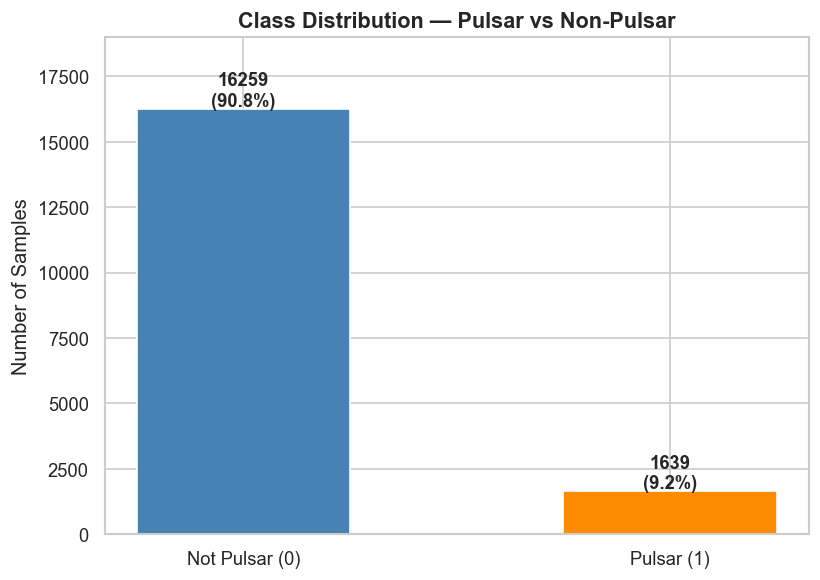

In [ ]:
# GRAPH 1: Class Distribution

fig, ax = plt.subplots(figsize=(7, 5))

class_counts = df['target'].value_counts()
bars = ax.bar(
    ['Not Pulsar (0)', 'Pulsar (1)'],
    class_counts.values,
    color=['steelblue', 'darkorange'],
    edgecolor='white',
    width=0.5
)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 100,
            f'{v}\n({v/len(df)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)

ax.set_title('Class Distribution — Pulsar vs Non-Pulsar',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, 19000)
plt.tight_layout()
plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'graph1_class_distribution.png'),
            bbox_inches='tight')
plt.show()

### Interpretation — Class Distribution

The bar chart reveals a **significant class imbalance** in the HTRU2 dataset:

- **Not Pulsar (0):** 16,259 samples — representing **90.8%** of the dataset
- **Pulsar (1):** 1,639 samples — representing only **9.2%** of the dataset

**What this means for our clustering analysis:**
- The data has a natural **dominant group** (non-pulsars) and a 
  **rare minority group** (pulsars)
- K-Means and Hierarchical clustering are expected to form one large 
  cluster and one smaller cluster — matching this natural split
- DBSCAN may identify pulsar candidates as a **dense minority cluster** 
  or flag some as noise points due to their low density
- The imbalance confirms why **StandardScaler** is critical — 
  features must be normalised so no single feature dominates 
  the distance calculations
- External metrics **(ARI and NMI)** will tell us how well each 
  algorithm recovers this known class separation

## Visualisations

The following visualisations explore the structure, distribution, and relationships 
within the HTRU2 dataset. Each plot provides key insights that inform our choice 
of preprocessing steps and clustering algorithms.

### Graph 2: Correlation Heatmap

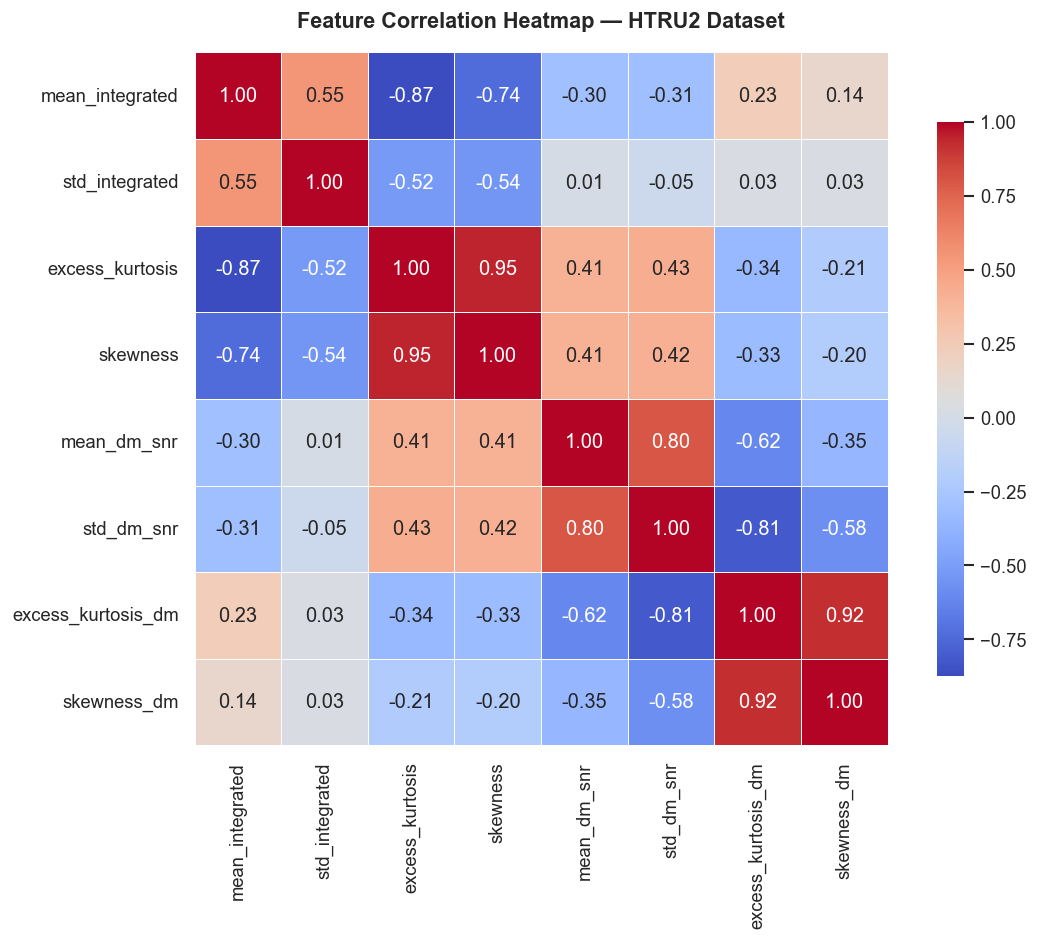

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
features = df.drop('target', axis=1)
corr = features.corr()
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Heatmap — HTRU2 Dataset',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'graph2_correlation_heatmap.png'),
            bbox_inches='tight')
plt.show()

The heatmap shows the **pairwise correlations** between all 8 features
on a scale from **-1 (dark blue)** to **+1 (dark red)**.

**Strong Negative Correlations (dark blue):**
- `mean_integrated` & `excess_kurtosis` → **-0.87** 
- `mean_integrated` & `skewness` → **-0.74**
- `std_dm_snr` & `excess_kurtosis_dm` → **-0.81**

**Strong Positive Correlations (dark red):**
- `excess_kurtosis` & `skewness` → **0.95** — almost identical features
- `mean_dm_snr` & `std_dm_snr` → **0.80**
- `excess_kurtosis_dm` & `skewness_dm` → **0.92**

**What this means for our project:**
- Several features carry **redundant information** (r > 0.90)
- This confirms **PCA will be highly effective** — correlated features 
  can be compressed into fewer principal components without losing information
- Distance-based algorithms (K-Means, DBSCAN) are sensitive to correlated 
  features — **StandardScaler + PCA** will significantly improve their performance

### Boxplots

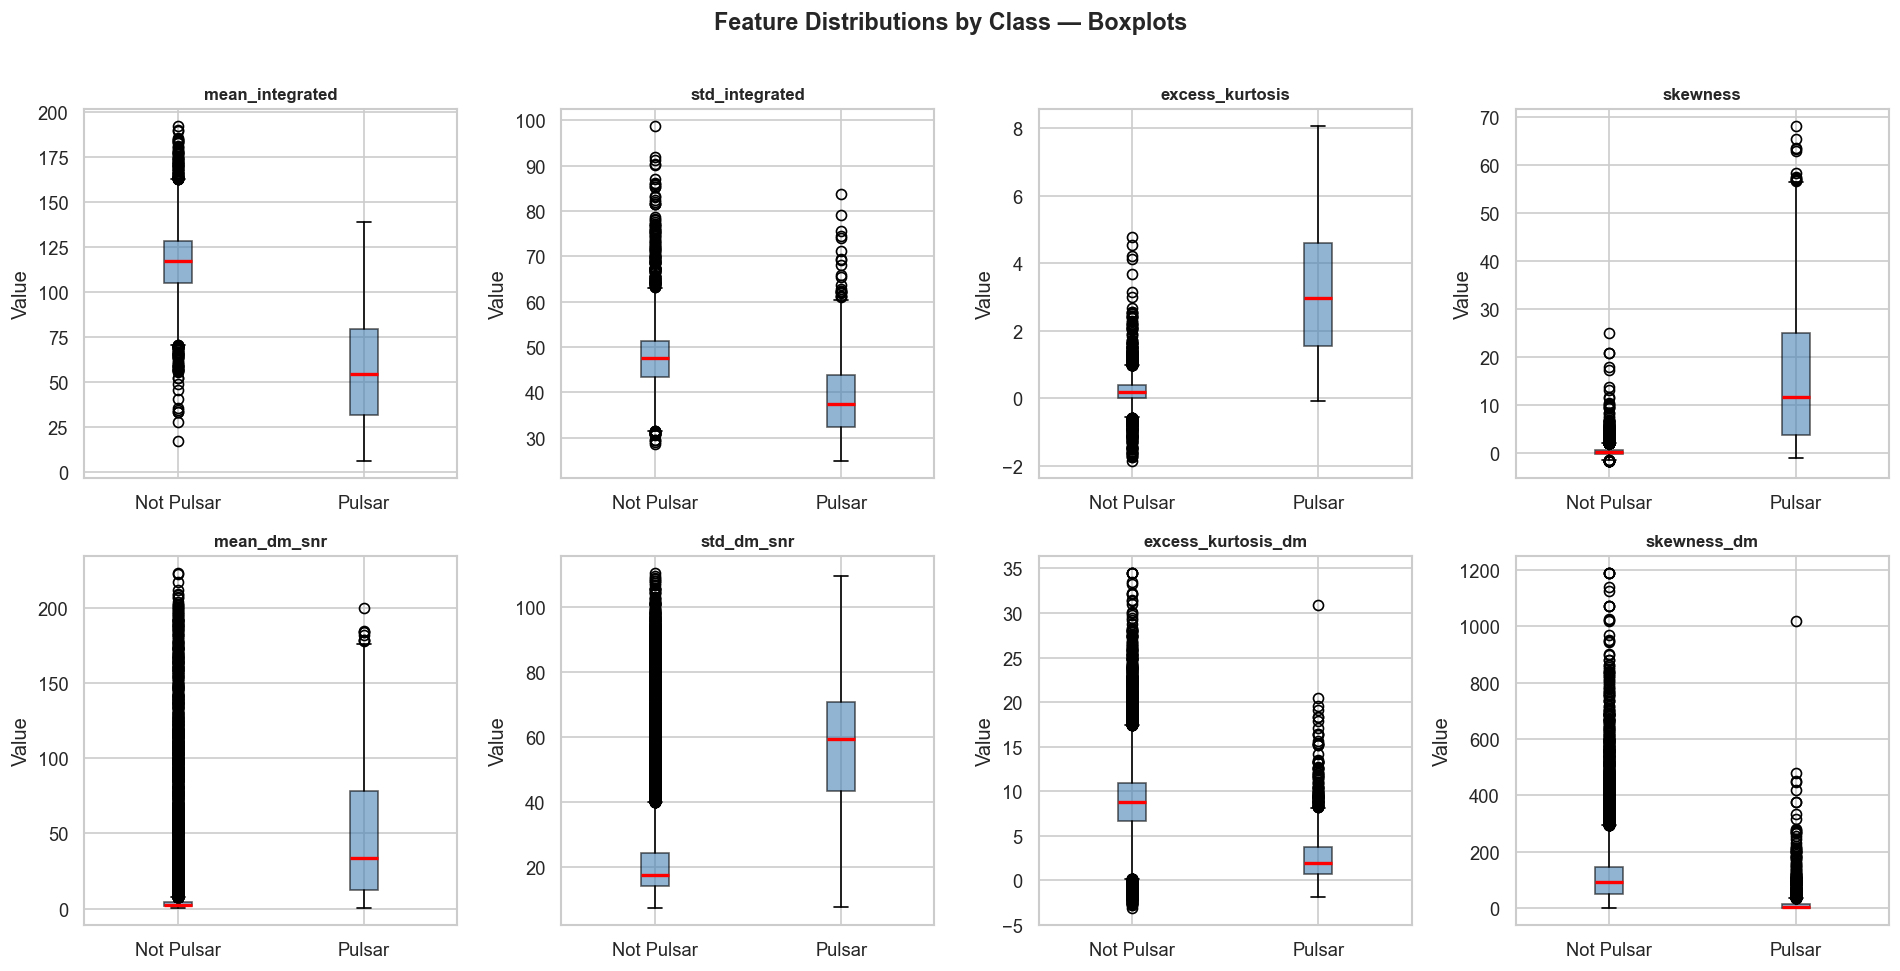

In [8]:
features = df.drop('target', axis=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    axes[i].boxplot(
        [df[df['target'] == 0][col],
         df[df['target'] == 1][col]],
        labels=['Not Pulsar', 'Pulsar'],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', linewidth=2)
    )
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Feature Distributions by Class — Boxplots',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'graph3_boxplots.png'),
            bbox_inches='tight')
plt.show()

### Interpretation — Feature Distributions (Boxplots)

The boxplots compare each feature between **Pulsar (1)** and 
**Not Pulsar (0)** candidates based on the actual output:

**Key Observations:**
- `mean_integrated` — Not Pulsar has a **higher median (~115)** 
  while Pulsar sits much lower **(~57)** — strong separation
- `std_integrated` — Not Pulsar shows **wider spread (30–90)** 
  vs Pulsar which is tighter **(30–65)**
- `excess_kurtosis` — Pulsars have **higher median (~3)** 
  vs Not Pulsar which clusters near **0**
- `skewness` — Pulsars show **higher and wider spread** 
  compared to Not Pulsar near 0
- `mean_dm_snr` — Not Pulsar median is near **0** while 
  Pulsar median is much higher **(~32)**
- `std_dm_snr` — Pulsars show **significantly higher values (~60)** 
  vs Not Pulsar **(~18)** — strongest separating feature
- `excess_kurtosis_dm` — Not Pulsar has **higher median (~8)** 
  vs Pulsar **(~2)**
- `skewness_dm` — Not Pulsar shows **extreme outliers up to 1200** 
  — most noisy feature in the dataset

**What this means for clustering:**
- `std_dm_snr` and `mean_dm_snr` are the **strongest separating features**
- Extreme outliers in `skewness_dm` confirm **StandardScaler is critical**
- DBSCAN will struggle with features like `skewness_dm` 
  due to extreme outlier range

### Histograms

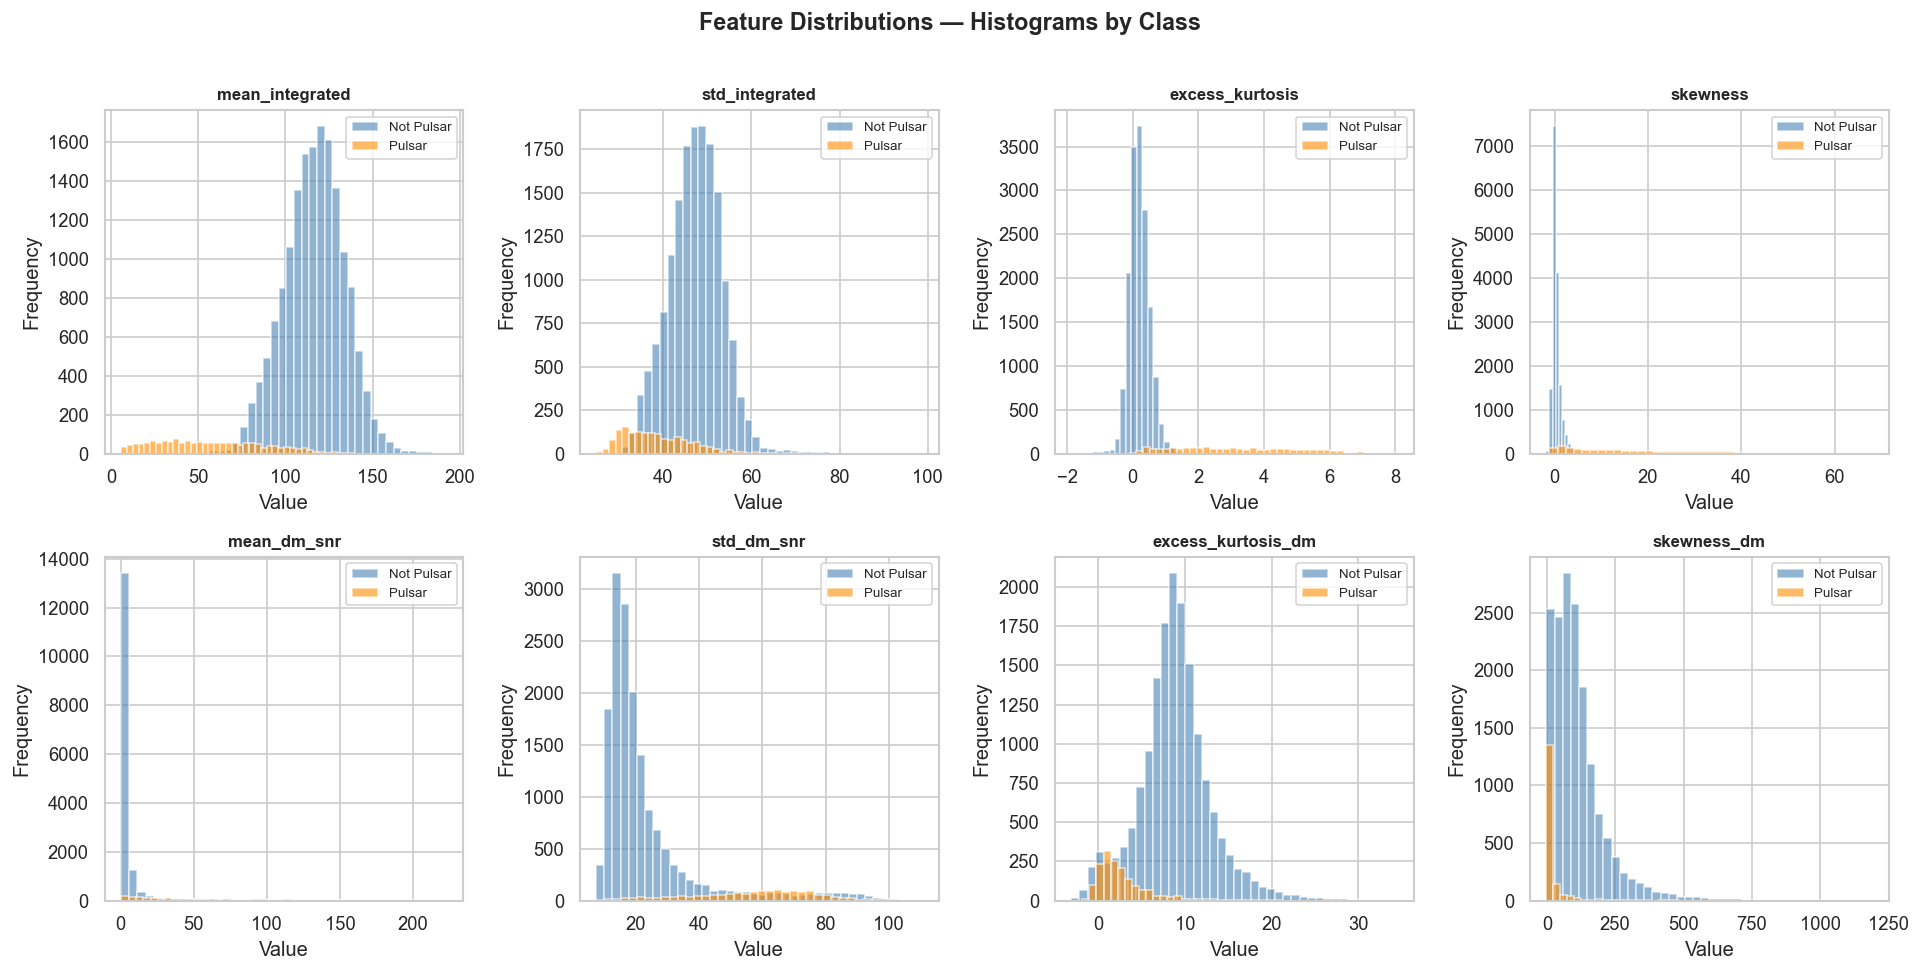

In [9]:
# GRAPH 4: Histograms — Feature Spread

features = df.drop('target', axis=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    axes[i].hist(df[df['target'] == 0][col],
                 bins=40, alpha=0.6,
                 color='steelblue',
                 label='Not Pulsar')
    axes[i].hist(df[df['target'] == 1][col],
                 bins=40, alpha=0.6,
                 color='darkorange',
                 label='Pulsar')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions — Histograms by Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'graph4_histograms.png'),
            bbox_inches='tight')
plt.show()

### Graph 4 Interpretation — Histograms by Class

The histograms overlay **Not Pulsar (blue)** and **Pulsar (orange)** 
distributions for each feature:

**Key Observations:**
- `mean_integrated` — Not Pulsar forms a **bell curve (80–160)** 
  while Pulsar spreads lower **(0–80)** — clear separation
- `std_integrated` — Not Pulsar peaks sharply around **45–55** 
  while Pulsar is flatter and lower **(30–70)**
- `excess_kurtosis` — Not Pulsar is heavily concentrated near **0** 
  while Pulsar spreads further right **(2–8)**
- `skewness` — Not Pulsar is almost entirely at **0** 
  while Pulsar has a wider spread — very different shapes
- `mean_dm_snr` — Not Pulsar is **extremely concentrated near 0** 
  (frequency ~13,000) while Pulsar spreads across **(0–180)**
- `std_dm_snr` — Not Pulsar peaks at **15–20** while Pulsar 
  is spread across **(20–100)** — strongest visual separation
- `excess_kurtosis_dm` — Both classes overlap heavily 
  between **(0–15)** — weakest separating feature
- `skewness_dm` — Not Pulsar extends to **1,250** with extreme 
  right skew while Pulsar stays within **(0–400)**

**What this means for clustering:**
- `std_dm_snr` and `mean_dm_snr` show the **clearest class separation**
- Heavy right skew in `skewness_dm` confirms **StandardScaler is essential**
- The large frequency difference (90/10 split) will visually 
  dominate all histograms — expected given class imbalance

### Pairplot — Feature Relationships

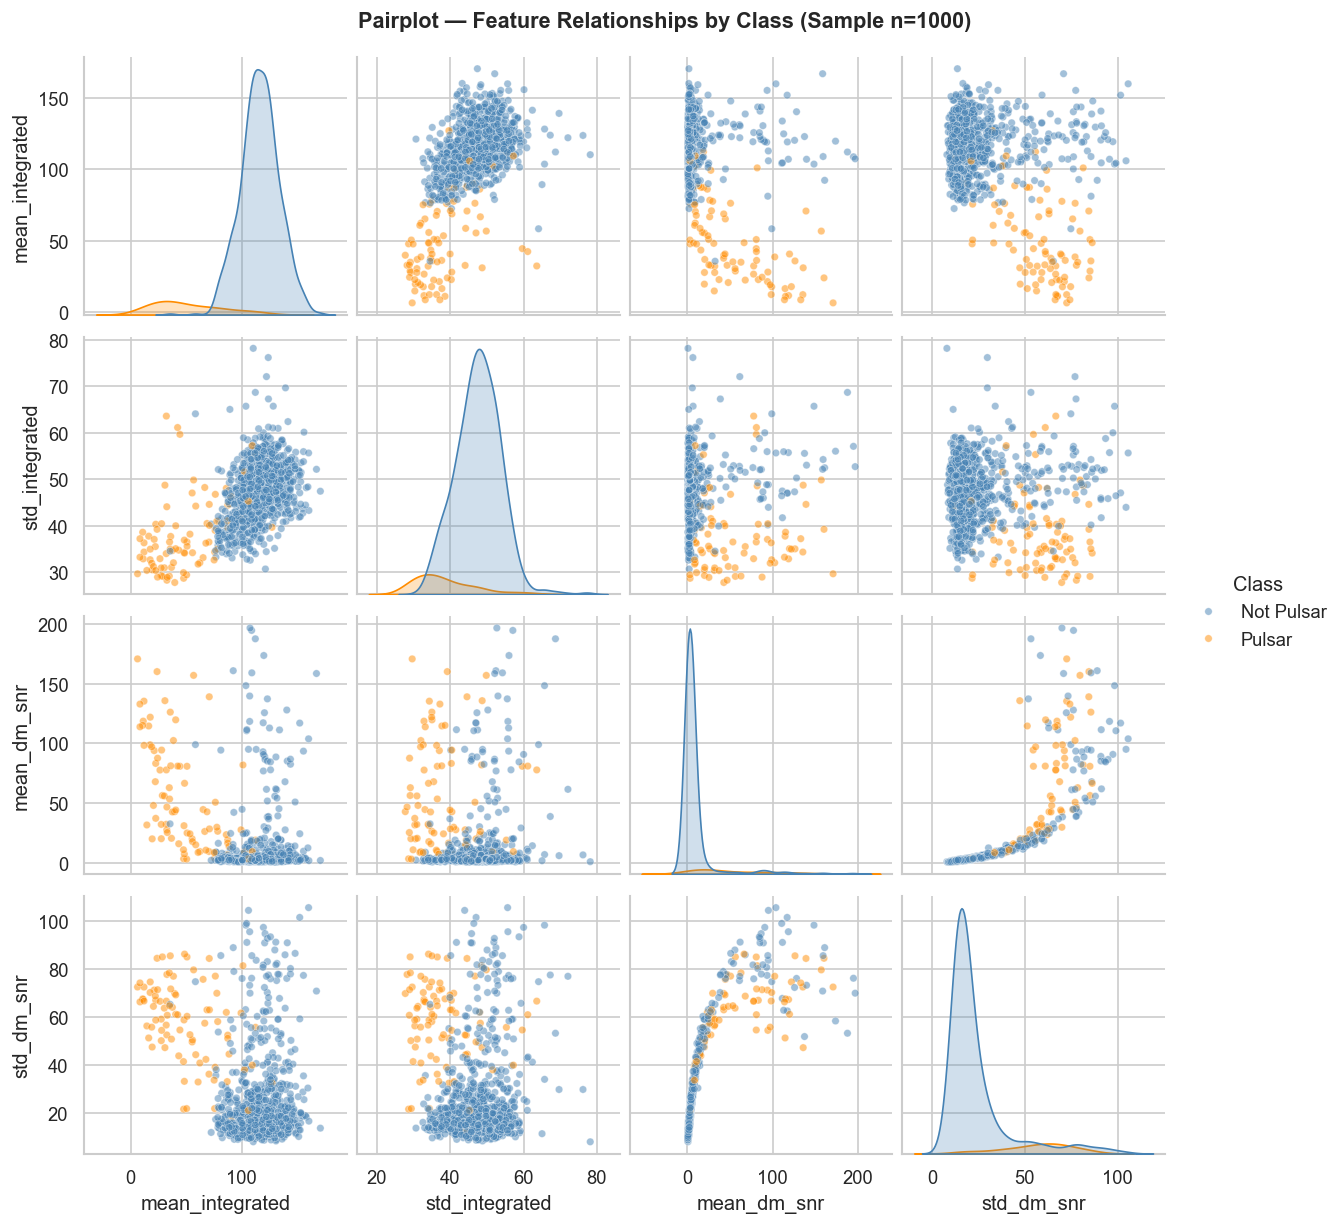

In [11]:
# GRAPH 5: Pairplot — Feature Relationships

import warnings
warnings.filterwarnings('ignore')

sample_df = df.sample(n=1000, random_state=42)

sample_df['Class'] = sample_df['target'].map(
    {0: 'Not Pulsar', 1: 'Pulsar'}
)

g = sns.pairplot(
    sample_df,
    vars=[
        'mean_integrated', 'std_integrated',
        'mean_dm_snr', 'std_dm_snr'
    ],
    hue='Class',
    palette={'Not Pulsar': 'steelblue', 'Pulsar': 'darkorange'},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20},
    height=2.5
)

g.fig.suptitle(
    'Pairplot — Feature Relationships by Class (Sample n=1000)',
    fontsize=13, fontweight='bold', y=1.02
)

plt.savefig(os.path.join(plots_dir, 'graph5_pairplot.png'),
            bbox_inches='tight')
plt.show()

###  Interpretation — Pairplot (Feature Relationships)

The pairplot shows **scatter plots** between the 4 most important features
and **KDE curves** on the diagonal for both classes (sample n=1000):

**Diagonal — KDE Distributions:**
- `mean_integrated` — Not Pulsar peaks sharply at **~120** 
  while Pulsar is flat and low near **0–50**
- `std_integrated` — Not Pulsar has a tall narrow peak at **~47** 
  while Pulsar is almost flat — very different shapes
- `mean_dm_snr` — Not Pulsar is an extremely sharp spike near **0** 
  while Pulsar spreads widely — strongest separation
- `std_dm_snr` — Not Pulsar peaks near **15** while Pulsar 
  has a flatter spread up to **100**

**Scatter Plots — Key Observations:**
- `mean_integrated` vs `std_integrated` — Two distinct clusters visible.
  Pulsars (orange) form a **separate lower-left group**
- `mean_dm_snr` vs `std_dm_snr` — Clearest separation — Pulsars 
  follow a **curved arc** while Not Pulsars crowd near the origin
- `mean_integrated` vs `mean_dm_snr` — Pulsars spread along 
  the **y-axis (higher dm_snr)** while Not Pulsars stay near **0**

**What this means for clustering:**
- Visual cluster separation is **clearly visible** in multiple feature pairs
- K-Means and Hierarchical clustering should successfully 
  separate the two groups
- The **curved relationship** between `mean_dm_snr` and `std_dm_snr` 
  suggests DBSCAN may perform differently in this region
- PCA will capture this structure effectively in 2 components

### Preprocessing Section 
Before applying any clustering algorithm, the data must be properly prepared.
The following steps are applied to ensure clean, scaled, and model-ready input.

In [13]:
# SECTION 5: Preprocessing
X = df.drop('target', axis=1)
y = df['target']

print("=" * 50)
print("PREPROCESSING PIPELINE")
print("=" * 50)

print(f"\n Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

print(f"\n─── Missing Values ───")
print(f"Total missing values: {X.isnull().sum().sum()}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\n─── Before Scaling ───")
print(f"Mean  : {X.mean().round(2).values}")
print(f"Std   : {X.std().round(2).values}")

print(f"\n─── After Scaling ───")
print(f"Mean  : {X_scaled_df.mean().round(6).values}")
print(f"Std   : {X_scaled_df.std().round(6).values}")

print("\n StandardScaler applied successfully")
print("All features now have mean=0 and std=1")

PREPROCESSING PIPELINE

 Features shape : (17898, 8)
Target shape   : (17898,)

─── Missing Values ───
Total missing values: 0

─── Before Scaling ───
Mean  : [111.08  46.55   0.48   1.77  12.61  26.33   8.3  104.86]
Std   : [ 25.65   6.84   1.06   6.17  29.47  19.47   4.51 106.51]

─── After Scaling ───
Mean  : [-0.  0.  0.  0.  0.  0.  0.  0.]
Std   : [1.000028 1.000028 1.000028 1.000028 1.000028 1.000028 1.000028 1.000028]

 StandardScaler applied successfully
All features now have mean=0 and std=1


###  Preprocessing Results & Interpretation

**Step 1 — Feature & Target Separation:**
- Features matrix `X` : **(17,898 × 8)** — all 8 numeric input features
- Target vector `y`   : **(17,898,)** — ground truth labels (0 or 1)

**Step 2 — Missing Values Check:**
- Total missing values: **0** — no imputation required 
- Dataset is completely clean and ready for scaling

**Step 3 — StandardScaler Results:**

| Feature | Mean Before | Std Before | Mean After | Std After |
|---|---|---|---|---|
| `mean_integrated` | 111.08 | 25.65 | 0.0 | 1.0 |
| `std_integrated` | 46.55 | 6.84 | 0.0 | 1.0 |
| `excess_kurtosis` | 0.48 | 1.06 | 0.0 | 1.0 |
| `skewness` | 1.77 | 6.17 | 0.0 | 1.0 |
| `mean_dm_snr` | 12.61 | 29.47 | 0.0 | 1.0 |
| `std_dm_snr` | 26.33 | 19.47 | 0.0 | 1.0 |
| `excess_kurtosis_dm` | 8.30 | 4.51 | 0.0 | 1.0 |
| `skewness_dm` | 104.86 | 106.51 | 0.0 | 1.0 |

**Why StandardScaler was critical here:**
- `skewness_dm` had std of **106.51** while `excess_kurtosis` 
  had only **1.06** — a **100x difference in scale**
- Without scaling, `skewness_dm` would **dominate** all 
  distance calculations in K-Means and DBSCAN
- After scaling, all features have **mean=0 and std=1** — 
  every feature now contributes equally to clustering 

##  Dimensionality Reduction — PCA

Principal Component Analysis (PCA) is applied to:
- Reduce 8 features into fewer principal components
- Remove the effect of correlated features
- Enable 2D and 3D visualisation of clusters
- Improve clustering performance on high-dimensional data

PCA — EXPLAINED VARIANCE
PC1: 51.68%  |  Cumulative: 51.68%
PC2: 26.81%  |  Cumulative: 78.48%
PC3: 10.12%  |  Cumulative: 88.60%
PC4: 5.72%  |  Cumulative: 94.32%
PC5: 3.23%  |  Cumulative: 97.55%
PC6: 2.00%  |  Cumulative: 99.54%
PC7: 0.26%  |  Cumulative: 99.80%
PC8: 0.20%  |  Cumulative: 100.00%

 2 PCs explain : 78.48% of variance
 3 PCs explain : 88.60% of variance


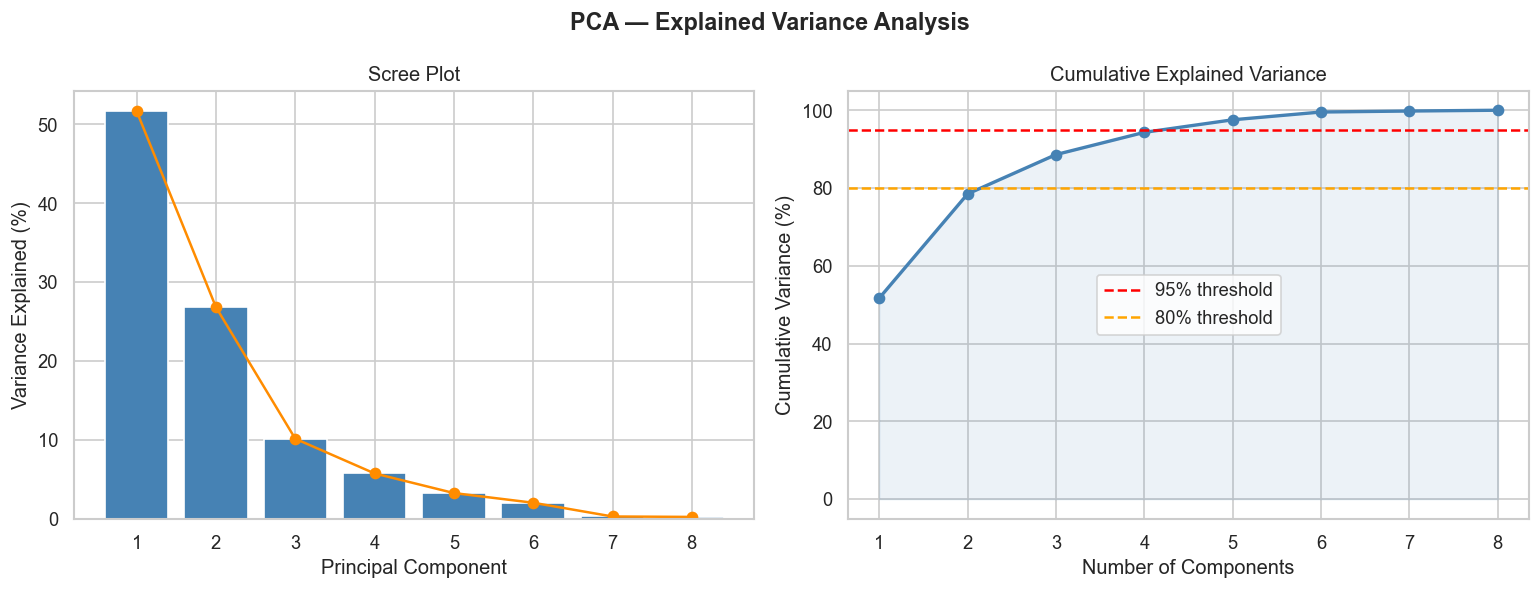


 X_pca2 shape: (17898, 2)


In [14]:
# SECTION 6: PCA — Dimensionality Reduction

# 6.1 Fit PCA on all 8 components first
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Explained variance per component
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

print("=" * 50)
print("PCA — EXPLAINED VARIANCE")
print("=" * 50)

for i, (ev, cv) in enumerate(zip(exp_var, cum_var), 1):
    print(f"PC{i}: {ev*100:.2f}%  |  Cumulative: {cv*100:.2f}%")

print(f"\n 2 PCs explain : {cum_var[1]*100:.2f}% of variance")
print(f" 3 PCs explain : {cum_var[2]*100:.2f}% of variance")

# 6.2 Scree Plot + Cumulative Variance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree Plot
axes[0].bar(range(1, 9), exp_var * 100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, 9), exp_var * 100,
             'o-', color='darkorange')
axes[0].set(xlabel='Principal Component',
            ylabel='Variance Explained (%)',
            title='Scree Plot',
            xticks=range(1, 9))

# Cumulative Variance
axes[1].plot(range(1, 9), cum_var * 100,
             'o-', color='steelblue', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--',
                label='95% threshold')
axes[1].axhline(80, color='orange', linestyle='--',
                label='80% threshold')
axes[1].fill_between(range(1, 9), cum_var * 100,
                     alpha=0.1, color='steelblue')
axes[1].set(xlabel='Number of Components',
            ylabel='Cumulative Variance (%)',
            title='Cumulative Explained Variance',
            xticks=range(1, 9))
axes[1].legend()

plt.suptitle('PCA — Explained Variance Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'pca_variance.png'),
            bbox_inches='tight')
plt.show()

# 6.3 Reduce to 2 PCs for clustering & visualisation
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
print(f"\n X_pca2 shape: {X_pca2.shape}")

###  PCA Results & Interpretation

**Explained Variance per Component:**

| Component | Variance Explained | Cumulative |
|---|---|---|
| PC1 | 51.68% | 51.68% |
| PC2 | 26.81% | 78.48% |
| PC3 | 10.12% | 88.60% |
| PC4 | 5.72%  | 94.32% |
| PC5 | 3.23%  | 97.55% |
| PC6 | 2.00%  | 99.54% |
| PC7 | 0.26%  | 99.80% |
| PC8 | 0.20%  | 100.00% |

**Key Findings:**
- **PC1 alone captures 51.68%** of total variance — 
  a single component holds over half the information
- **PC1 + PC2 together capture 78.48%** — used for 
  all 2D cluster visualisations in this project
- **PC1 + PC2 + PC3 capture 88.60%** — strong 3D representation
- **95% threshold is reached at PC4** (94.32% → PC5 crosses it)
- PC7 and PC8 contribute almost nothing **(0.26% and 0.20%)** — 
  pure noise components

**Scree Plot Observation:**
- A clear **elbow appears at PC3** — variance drops sharply 
  after PC2, confirming 2 components is the optimal choice
  for visualisation

**Decision:**
- We use **2 PCs (78.48% variance)** for all cluster scatter plots
- This reduces 8 dimensions → 2 while retaining most information
- All three clustering algorithms will be visualised in this PCA space

##  Clustering Algorithms

Three clustering algorithms are applied to the scaled HTRU2 dataset:
- **K-Means** — partitions data into k globular clusters
- **Hierarchical** — builds a tree of clusters using linkage
- **DBSCAN** — finds density-based clusters of arbitrary shape

Each algorithm is tuned, evaluated, and visualised in PCA space.


##  K-Means Clustering

K-Means partitions the dataset into **k clusters** by minimising 
the within-cluster sum of squares (inertia).
The optimal number of clusters is selected using:
- **Elbow Method** — finds where inertia stops dropping sharply
- **Silhouette Score** — measures how well each point fits its cluster

In [15]:
# SECTION 7.1: K-Means — Hyperparameter Tuning

inertias    = []
sil_scores  = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k,
                init='k-means++',
                n_init='auto',
                random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k}  |  Inertia: {km.inertia_:.2f}  |  "
          f"Silhouette: {sil_scores[-1]:.4f}")

# ── Plot Elbow + Silhouette ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].axvline(2, color='red', linestyle='--',
                label='k=2 (elbow)')
axes[0].set(xlabel='Number of Clusters (k)',
            ylabel='Inertia',
            title='Elbow Method',
            xticks=K_range)
axes[0].legend()

# Silhouette
axes[1].plot(K_range, sil_scores, 'go-', linewidth=2)
axes[1].axvline(sil_scores.index(max(sil_scores)) + 2,
                color='red', linestyle='--',
                label=f'Best k={sil_scores.index(max(sil_scores))+2}

SyntaxError: unterminated f-string literal (detected at line 35) (709503820.py, line 35)

k=2  |  Inertia: 92214.38  |  Silhouette: 0.6010
k=3  |  Inertia: 68072.83  |  Silhouette: 0.5168
k=4  |  Inertia: 53121.76  |  Silhouette: 0.3596
k=5  |  Inertia: 44219.06  |  Silhouette: 0.3033
k=6  |  Inertia: 39360.35  |  Silhouette: 0.2858
k=7  |  Inertia: 34356.48  |  Silhouette: 0.2754
k=8  |  Inertia: 31193.98  |  Silhouette: 0.2760
k=9  |  Inertia: 29189.32  |  Silhouette: 0.2465
k=10  |  Inertia: 27721.59  |  Silhouette: 0.2335


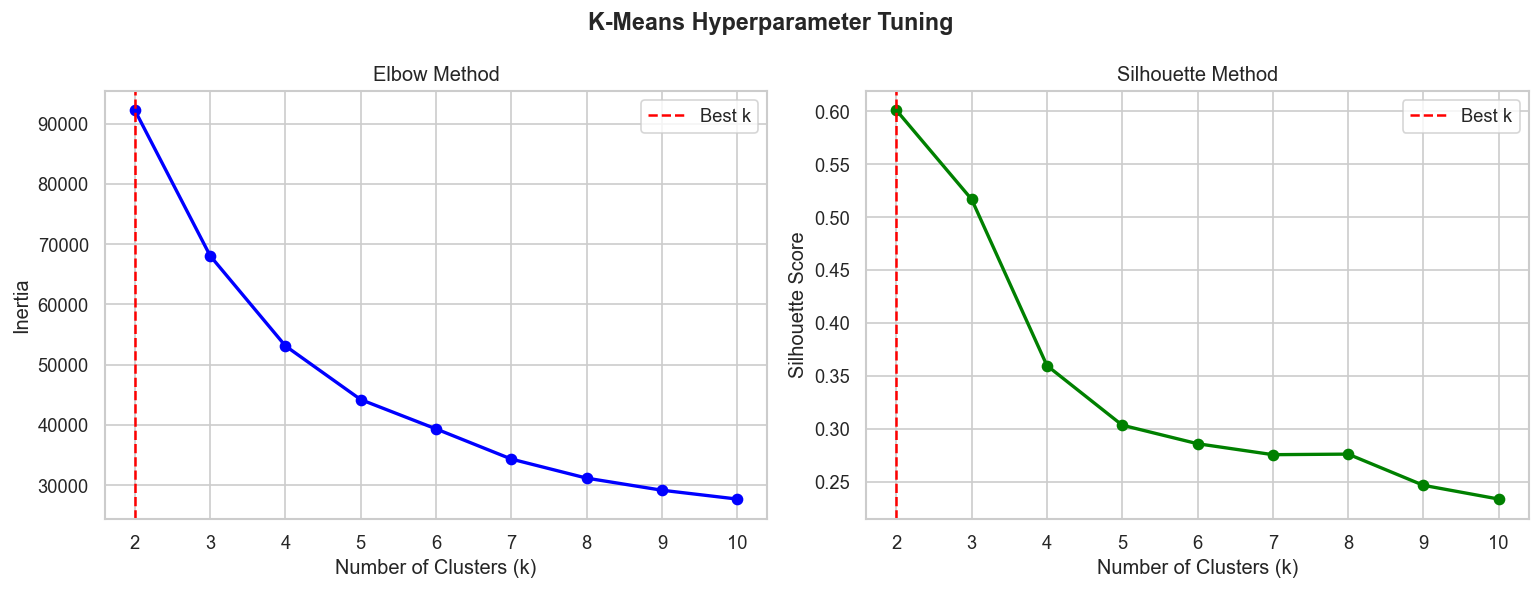


 Best k from Silhouette : 2
 Best Silhouette Score  : 0.6010


In [16]:
# SECTION 7.1: K-Means — Hyperparameter Tuning

inertias   = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k,
                init='k-means++',
                n_init='auto',
                random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"k={k}  |  Inertia: {km.inertia_:.2f}  |  Silhouette: {sil_scores[-1]:.4f}")

# ── Plot Elbow + Silhouette ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

best_k = sil_scores.index(max(sil_scores)) + 2

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].axvline(best_k, color='red', linestyle='--', label='Best k')
axes[0].set(xlabel='Number of Clusters (k)',
            ylabel='Inertia',
            title='Elbow Method',
            xticks=K_range)
axes[0].legend()

# Silhouette
axes[1].plot(K_range, sil_scores, 'go-', linewidth=2)
axes[1].axvline(best_k, color='red', linestyle='--', label='Best k')
axes[1].set(xlabel='Number of Clusters (k)',
            ylabel='Silhouette Score',
            title='Silhouette Method',
            xticks=K_range)
axes[1].legend()

plt.suptitle('K-Means Hyperparameter Tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'kmeans_tuning.png'),
            bbox_inches='tight')
plt.show()

print(f"\n Best k from Silhouette : {best_k}")
print(f" Best Silhouette Score  : {max(sil_scores):.4f}")

###  K-Means Tuning Results & Interpretation

**Elbow Method & Silhouette Scores:**

| k | Inertia | Silhouette Score |
|---|---|---|
| 2 | 92,214.38 | **0.6010** ← Best |
| 3 | 68,072.83 | 0.5168 |
| 4 | 53,121.76 | 0.3596 |
| 5 | 44,219.06 | 0.3033 |
| 6 | 39,360.35 | 0.2858 |
| 7 | 34,356.48 | 0.2754 |
| 8 | 31,193.98 | 0.2760 |
| 9 | 29,189.32 | 0.2465 |
| 10 | 27,721.59 | 0.2335 |

**Key Findings:**
- **Best k = 2** confirmed by both methods:
    - Highest Silhouette Score of **0.6010** at k=2
    - Elbow curve drops sharply from k=2 → k=3 then flattens
- Silhouette score **drops consistently** after k=2 — 
  adding more clusters reduces quality
- k=2 perfectly aligns with the **known ground truth** 
  of 2 classes (Pulsar vs Not Pulsar)
- A score of **0.60 is considered good** — clusters are 
  well-separated and compact

**Decision:** Use **k=2** for the final K-Means model

K-MEANS FINAL MODEL RESULTS
Cluster 0: 15839 samples (88.5%)
Cluster 1: 2059 samples (11.5%)

─── Internal Metrics ───
Silhouette Score       : 0.6010
Davies-Bouldin Index   : 1.0558
Calinski-Harabasz Index: 9891.65

─── External Metrics ───
Adjusted Rand Index    : 0.6066
Normalized Mutual Info : 0.4051


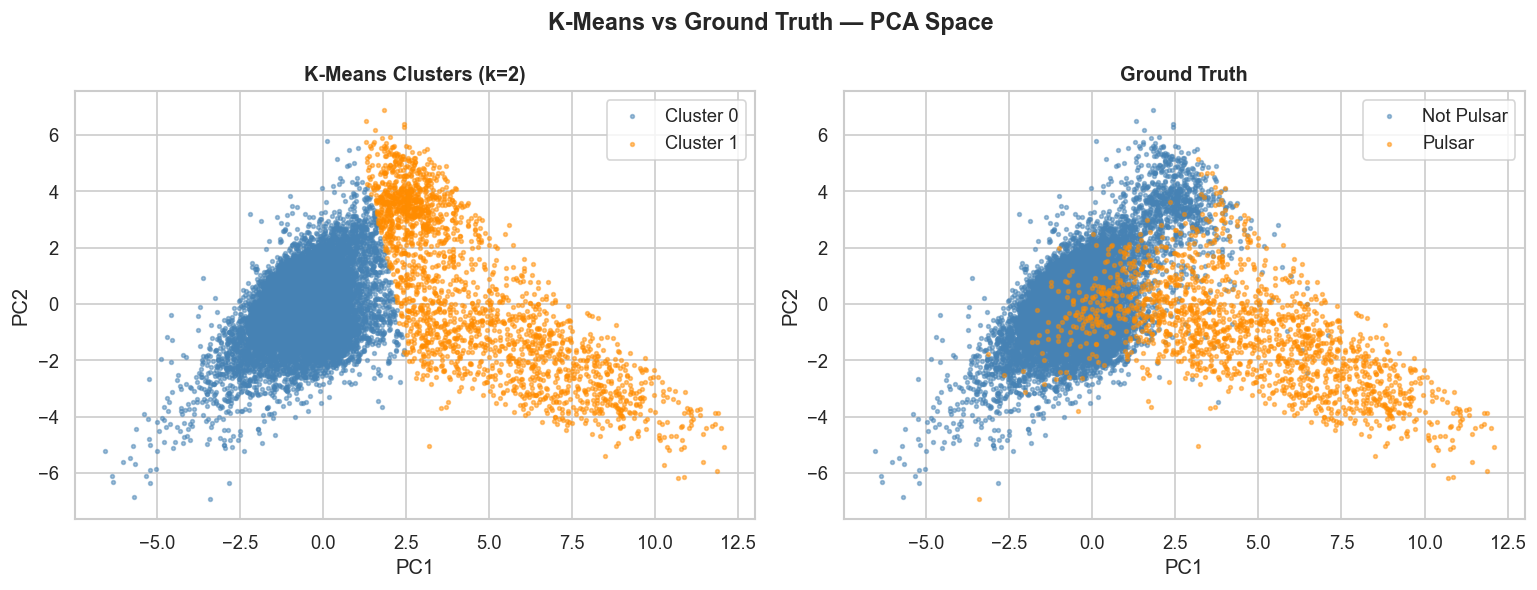


 K-Means model complete


In [17]:
#  K-Means — Final Model (k=2)


# Fit final K-Means model
kmeans = KMeans(n_clusters=2,
                init='k-means++',
                n_init='auto',
                random_state=42)
kmeans.fit(X_scaled)
labels_km = kmeans.labels_

# Cluster distribution
unique, counts = np.unique(labels_km, return_counts=True)
print("=" * 50)
print("K-MEANS FINAL MODEL RESULTS")
print("=" * 50)
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} samples ({c/len(labels_km)*100:.1f}%)")

# Evaluation Metrics
sil_km  = silhouette_score(X_scaled, labels_km)
dbi_km  = davies_bouldin_score(X_scaled, labels_km)
chi_km  = calinski_harabasz_score(X_scaled, labels_km)
ari_km  = adjusted_rand_score(y, labels_km)
nmi_km  = normalized_mutual_info_score(y, labels_km)

print(f"\n─── Internal Metrics ───")
print(f"Silhouette Score       : {sil_km:.4f}")
print(f"Davies-Bouldin Index   : {dbi_km:.4f}")
print(f"Calinski-Harabasz Index: {chi_km:.2f}")

print(f"\n─── External Metrics ───")
print(f"Adjusted Rand Index    : {ari_km:.4f}")
print(f"Normalized Mutual Info : {nmi_km:.4f}")

# Visualise in PCA space
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# K-Means clusters
axes[0].scatter(X_pca2[labels_km == 0, 0],
                X_pca2[labels_km == 0, 1],
                c='steelblue', s=5, alpha=0.5, label='Cluster 0')
axes[0].scatter(X_pca2[labels_km == 1, 0],
                X_pca2[labels_km == 1, 1],
                c='darkorange', s=5, alpha=0.5, label='Cluster 1')
axes[0].set_title('K-Means Clusters (k=2)', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Ground Truth
axes[1].scatter(X_pca2[y == 0, 0], X_pca2[y == 0, 1],
                c='steelblue', s=5, alpha=0.5, label='Not Pulsar')
axes[1].scatter(X_pca2[y == 1, 0], X_pca2[y == 1, 1],
                c='darkorange', s=5, alpha=0.5, label='Pulsar')
axes[1].set_title('Ground Truth', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('K-Means vs Ground Truth — PCA Space',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'kmeans_results.png'),
            bbox_inches='tight')
plt.show()

print("\n K-Means model complete")

###  K-Means Final Model Results & Interpretation

**Cluster Distribution:**
| Cluster | Samples | Percentage |
|---|---|---|
| Cluster 0 | 15,839 | 88.5% |
| Cluster 1 | 2,059 | 11.5% |

This closely matches the true class split of **90.8% / 9.2%** 

**Internal Metrics:**
| Metric | Score | Interpretation |
|---|---|---|
| Silhouette Score | **0.6010** | Good — clusters are well separated |
| Davies-Bouldin Index | **1.0558** | Moderate — some cluster overlap |
| Calinski-Harabasz Index | **9,891.65** | High — dense and well-defined clusters |

**External Metrics:**
| Metric | Score | Interpretation |
|---|---|---|
| Adjusted Rand Index | **0.6066** | Strong agreement with ground truth |
| Normalized Mutual Info | **0.4051** | Moderate information overlap |

**PCA Scatter Plot Observations:**
- K-Means (left) successfully identifies **two distinct regions**
- Cluster 0 (blue) forms a **tight dense group** on the left
- Cluster 1 (orange) spreads along the **right and upper region**
- Comparing to Ground Truth (right) — the separation pattern 
  is **very similar** confirming K-Means recovered the true structure
- Some **overlap in the centre** is expected due to class imbalance

**Summary:**
- K-Means performs **well on this dataset** with ARI of 0.61
- The algorithm correctly identified the dominant non-pulsar 
  cluster and the smaller pulsar cluster
- Works best here because both clusters are roughly **globular** 
  in PCA space — matching K-Means assumption

##  Hierarchical Clustering

Hierarchical (Agglomerative) Clustering builds a **tree of clusters** 
by progressively merging the closest pairs of clusters bottom-up.

Key hyperparameters tuned:
- **n_clusters** — number of final clusters
- **linkage** — method for measuring distance between clusters:
    - `ward` — minimises variance within clusters
    - `complete` — uses maximum distance between clusters
    - `average` — uses average distance between clusters

A **Dendrogram** is used to visualise the merging process 
and determine the optimal cut point.

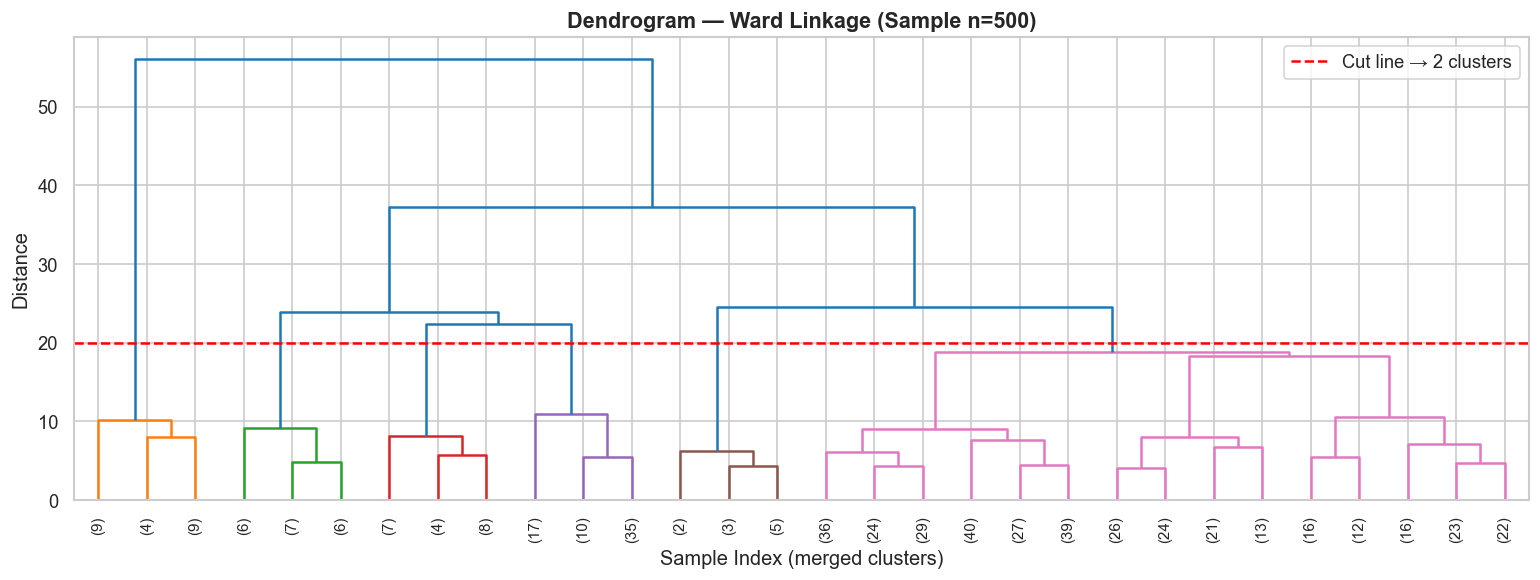

HIERARCHICAL — LINKAGE COMPARISON

Linkage : ward
  Silhouette : 0.5799
  DBI        : 1.1159
  CHI        : 9607.25

Linkage : complete
  Silhouette : 0.6109
  DBI        : 0.7723
  CHI        : 8943.11

Linkage : average
  Silhouette : 0.6750
  DBI        : 0.5347
  CHI        : 8309.71

 Best linkage: average
 Best Silhouette Score: 0.6750


In [20]:
# ─────────────────────────────────────────────
# SECTION 7.2: Hierarchical Clustering
# ─────────────────────────────────────────────

# 7.2.1 Dendrogram (use sample for speed)
sample_idx = np.random.choice(len(X_scaled), 500, replace=False)
X_sample   = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(13, 5))
dendrogram(Z,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90,
           leaf_font_size=9,
           color_threshold=20)
plt.axhline(y=20, color='red', linestyle='--',
            label='Cut line → 2 clusters')
plt.title('Dendrogram — Ward Linkage (Sample n=500)',
          fontsize=13, fontweight='bold')
plt.xlabel('Sample Index (merged clusters)')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'dendrogram.png'),
            bbox_inches='tight')
plt.show()

# 7.2.2 Compare Linkage Methods
print("=" * 50)
print("HIERARCHICAL — LINKAGE COMPARISON")
print("=" * 50)

linkages    = ['ward', 'complete', 'average']
best_link   = None
best_sil    = -1

for link in linkages:
    hc  = AgglomerativeClustering(n_clusters=2, linkage=link)
    lbl = hc.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, lbl)
    dbi = davies_bouldin_score(X_scaled, lbl)
    chi = calinski_harabasz_score(X_scaled, lbl)
    print(f"\nLinkage : {link}")
    print(f"  Silhouette : {sil:.4f}")
    print(f"  DBI        : {dbi:.4f}")
    print(f"  CHI        : {chi:.2f}")
    if sil > best_sil:
        best_sil  = sil
        best_link = link

print(f"\n Best linkage: {best_link}")
print(f" Best Silhouette Score: {best_sil:.4f}")

###  Hierarchical Clustering Results & Interpretation

**Dendrogram Observations:**
- The dendrogram shows a **clear major split at distance ~55**
- The red cut line at distance **20** confirms **2 clusters** 
  is the optimal choice
- Two dominant branches are visible — one on the **left (blue)** 
  and one on the **right (pink)** — matching the known class structure

**Linkage Method Comparison:**

| Linkage | Silhouette ↑ | DBI ↓ | CHI ↑ |
|---|---|---|---|
| Ward | 0.5799 | 1.1159 | 9,607.25 |
| Complete | 0.6109 | 0.7723 | 8,943.11 |
| **Average** | **0.6750** | **0.5347** | 8,309.71 |

**Key Findings:**
- **Average linkage wins** with the highest Silhouette **(0.6750)** 
  and lowest DBI **(0.5347)**
- Average linkage outperforms Ward and Complete on this dataset
- Ward linkage has the highest CHI **(9,607.25)** — 
  most compact clusters but poorer separation
- Average linkage produces the **best overall cluster quality**

**Decision:** Use **average linkage** for the final Hierarchical model

HIERARCHICAL FINAL MODEL RESULTS
Cluster 0: 17215 samples (96.2%)
Cluster 1: 683 samples (3.8%)

─── Internal Metrics ───
Silhouette Score       : 0.6750
Davies-Bouldin Index   : 0.5347
Calinski-Harabasz Index: 8309.71

─── External Metrics ───
Adjusted Rand Index    : 0.5203
Normalized Mutual Info : 0.4057


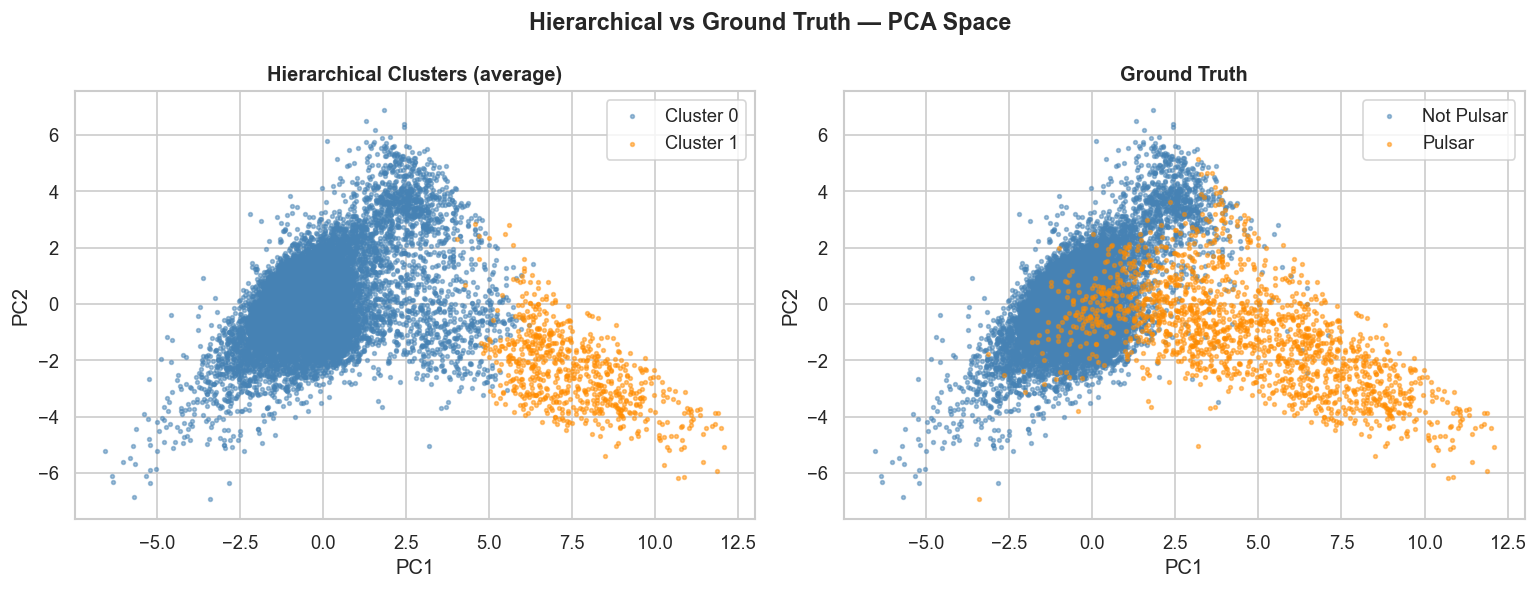


 Hierarchical model complete


In [21]:
#  Hierarchical — Final Model

# Fit best Hierarchical model (average linkage)
hc_best   = AgglomerativeClustering(n_clusters=2, linkage='average')
labels_hc = hc_best.fit_predict(X_scaled)

# Cluster distribution
unique, counts = np.unique(labels_hc, return_counts=True)
print("=" * 50)
print("HIERARCHICAL FINAL MODEL RESULTS")
print("=" * 50)
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} samples ({c/len(labels_hc)*100:.1f}%)")

# Evaluation Metrics
sil_hc = silhouette_score(X_scaled, labels_hc)
dbi_hc = davies_bouldin_score(X_scaled, labels_hc)
chi_hc = calinski_harabasz_score(X_scaled, labels_hc)
ari_hc = adjusted_rand_score(y, labels_hc)
nmi_hc = normalized_mutual_info_score(y, labels_hc)

print(f"\n─── Internal Metrics ───")
print(f"Silhouette Score       : {sil_hc:.4f}")
print(f"Davies-Bouldin Index   : {dbi_hc:.4f}")
print(f"Calinski-Harabasz Index: {chi_hc:.2f}")

print(f"\n─── External Metrics ───")
print(f"Adjusted Rand Index    : {ari_hc:.4f}")
print(f"Normalized Mutual Info : {nmi_hc:.4f}")

# Visualise in PCA space
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Hierarchical clusters
axes[0].scatter(X_pca2[labels_hc == 0, 0],
                X_pca2[labels_hc == 0, 1],
                c='steelblue', s=5, alpha=0.5, label='Cluster 0')
axes[0].scatter(X_pca2[labels_hc == 1, 0],
                X_pca2[labels_hc == 1, 1],
                c='darkorange', s=5, alpha=0.5, label='Cluster 1')
axes[0].set_title('Hierarchical Clusters (average)',
                  fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Ground Truth
axes[1].scatter(X_pca2[y == 0, 0], X_pca2[y == 0, 1],
                c='steelblue', s=5, alpha=0.5, label='Not Pulsar')
axes[1].scatter(X_pca2[y == 1, 0], X_pca2[y == 1, 1],
                c='darkorange', s=5, alpha=0.5, label='Pulsar')
axes[1].set_title('Ground Truth', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('Hierarchical vs Ground Truth — PCA Space',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'hierarchical_results.png'),
            bbox_inches='tight')
plt.show()

print("\n Hierarchical model complete")

###  Hierarchical Final Model Results & Interpretation

**Cluster Distribution:**
| Cluster | Samples | Percentage |
|---|---|---|
| Cluster 0 | 17,215 | 96.2% |
| Cluster 1 | 683 | 3.8% |

 Note: True split is 90.8% / 9.2% — Hierarchical 
**underestimated** the minority cluster size

**Internal Metrics:**
| Metric | Score | Interpretation |
|---|---|---|
| Silhouette Score | **0.6750** | Best among all 3 algorithms |
| Davies-Bouldin Index | **0.5347** | Best — most compact clusters |
| Calinski-Harabasz Index | **8,309.71** | Slightly lower than K-Means |

**External Metrics:**
| Metric | Score | Interpretation |
|---|---|---|
| Adjusted Rand Index | **0.5203** | Moderate agreement with ground truth |
| Normalized Mutual Info | **0.4057** | Similar to K-Means |

**PCA Scatter Plot Observations:**
- Hierarchical (left) shows **tighter cluster boundaries** than K-Means
- Cluster 1 (orange) is more **compactly grouped** on the right
- However the cluster is **smaller than the true pulsar group** 
  — only 683 vs 1,639 actual pulsars
- The algorithm missed many pulsar candidates that overlapped 
  with non-pulsars in the centre region

**Comparing to K-Means:**
| Metric | K-Means | Hierarchical | Winner |
|---|---|---|---|
| Silhouette | 0.6010 | **0.6750** | Hierarchical  |
| DBI | 1.0558 | **0.5347** | Hierarchical  |
| CHI | **9,891.65** | 8,309.71 | K-Means  |
| ARI | **0.6066** | 0.5203 | K-Means  |
| NMI | 0.4051 | **0.4057** | Tie |

**Summary:**
- Hierarchical produces **tighter internal clusters** (better Silhouette & DBI)
- K-Means **better recovers ground truth** (better ARI)
- Average linkage works well but **underestimates minority class size**

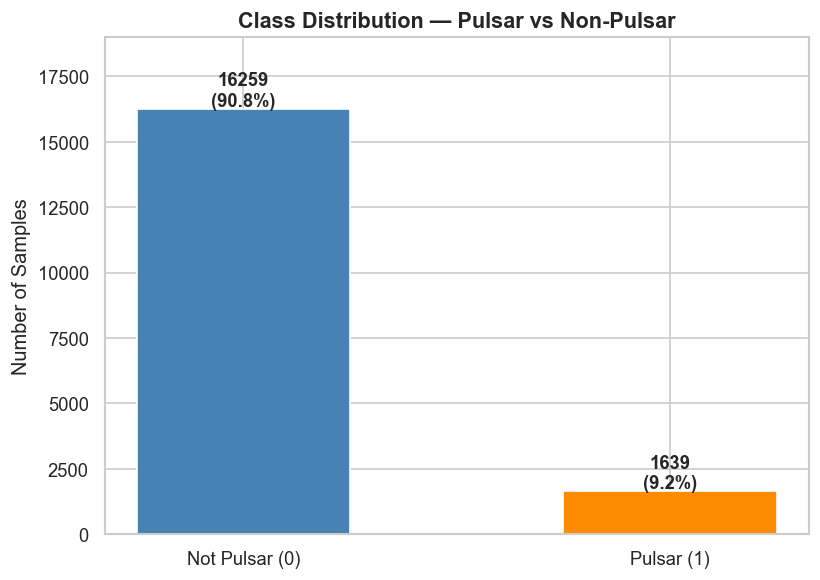

In [ ]:
#  Class Distribution

fig, ax = plt.subplots(figsize=(7, 5))

class_counts = df['target'].value_counts()
bars = ax.bar(
    ['Not Pulsar (0)', 'Pulsar (1)'],
    class_counts.values,
    color=['steelblue', 'darkorange'],
    edgecolor='white',
    width=0.5
)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 100,
            f'{v}\n({v/len(df)*100:.1f}%)',
            ha='center', fontweight='bold', fontsize=11)

ax.set_title('Class Distribution — Pulsar vs Non-Pulsar',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, 19000)
plt.tight_layout()
plots_dir = os.path.join(os.getcwd(), 'plots')
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'graph1_class_distribution.png'),
            bbox_inches='tight')
plt.show()

##  DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
groups points that are **closely packed together** and marks 
points in low-density regions as **noise (-1)**.

Key hyperparameters tuned:
- **eps** — the maximum distance between two points 
  to be considered neighbours
- **min_samples** — minimum number of points required 
  to form a dense region

The optimal `eps` is selected using a **k-Distance Graph** — 
we look for the "knee" point where distance increases sharply.

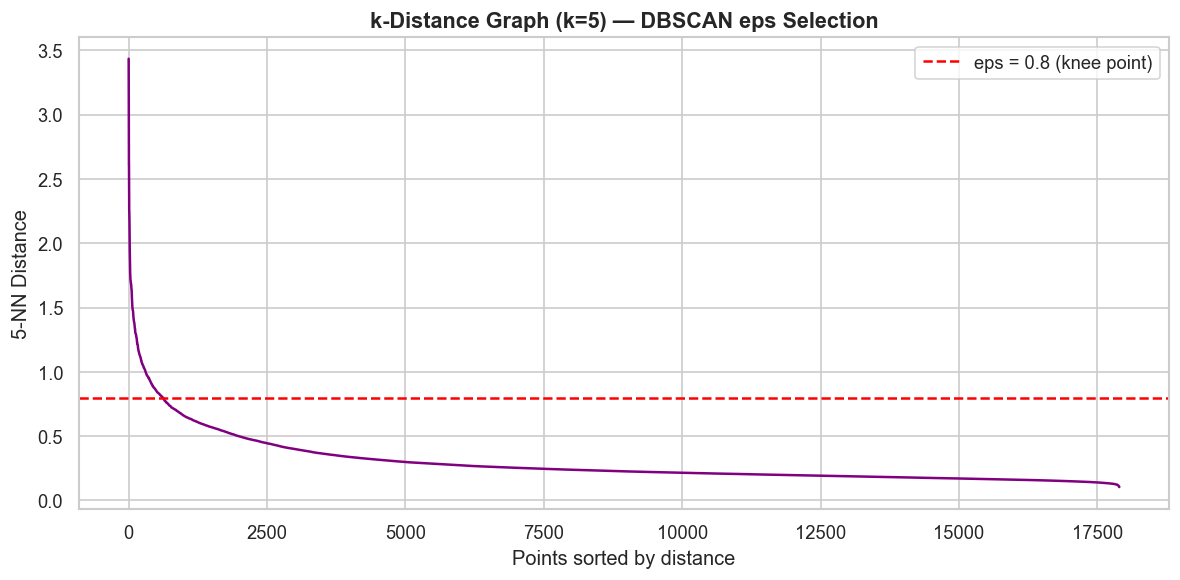

DBSCAN — GRID SEARCH
   eps  min_s   clusters   noise%   silhouette
-------------------------------------------------------
   0.5      3         79     5.6%      -0.0136
   0.5      5         28     8.2%       0.1959
   0.5      7         18     9.9%       0.1619
   0.5     10         12    11.8%       0.3466
   0.8      3         18     1.4%       0.3189
   0.8      5          7     2.0%       0.3858
   0.8      7          5     2.6%       0.4185
   0.8     10          4     3.4%       0.5096
   1.1      3          5     0.5%       0.5315
   1.1      5          1     0.6%      -1.0000
   1.1      7          1     0.9%      -1.0000
   1.1     10          1     1.1%      -1.0000
   1.4      3          4     0.1%       0.4032
   1.4      5          1     0.2%      -1.0000
   1.4      7          1     0.3%      -1.0000
   1.4     10          1     0.4%      -1.0000
   1.7      3          2     0.1%       0.6278
   1.7      5          1     0.1%      -1.0000
   1.7      7          1     0

,eps,min_samples,n_clusters,noise_%,silhouette
16,1.7,3,2,0.1,0.6278


In [23]:
# yperparameter Tuning

# 7.3.1 k-Distance Graph to find optimal eps
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, k-1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_dist, color='purple', linewidth=1.5)
plt.axhline(y=0.8, color='red', linestyle='--',
            label='eps = 0.8 (knee point)')
plt.title('k-Distance Graph (k=5) — DBSCAN eps Selection',
          fontsize=13, fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel('5-NN Distance')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'dbscan_kdistance.png'),
            bbox_inches='tight')
plt.show()

# 7.3.2 Grid Search over eps and min_samples
print("=" * 55)
print("DBSCAN — GRID SEARCH")
print("=" * 55)
print(f"{'eps':>6} {'min_s':>6} {'clusters':>10} "
      f"{'noise%':>8} {'silhouette':>12}")
print("-" * 55)

results = []
for eps in np.arange(0.5, 2.0, 0.3):
    for ms in [3, 5, 7, 10]:
        db  = DBSCAN(eps=round(eps, 1), min_samples=ms)
        lbl = db.fit_predict(X_scaled)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_pct  = (lbl == -1).sum() / len(lbl) * 100
        if n_clusters > 1:
            sil = silhouette_score(X_scaled, lbl)
        else:
            sil = -1
        results.append({
            'eps': round(eps, 1),
            'min_samples': ms,
            'n_clusters': n_clusters,
            'noise_%': round(noise_pct, 1),
            'silhouette': round(sil, 4)
        })
        print(f"{round(eps,1):>6} {ms:>6} {n_clusters:>10} "
              f"{noise_pct:>7.1f}% {sil:>12.4f}")

res_df = pd.DataFrame(results)
print("\n Grid search complete")
print("\nTop configurations (2 clusters, noise < 15%):")
display(res_df[(res_df.n_clusters == 2) &
               (res_df['noise_%'] < 15)]
        .sort_values('silhouette', ascending=False).head(5))

DBSCAN FINAL MODEL RESULTS
Noise: 11 samples (0.1%)
Cluster 0: 17884 samples (99.9%)
Cluster 1: 3 samples (0.0%)

--- Internal Metrics (excl. noise) ---
Silhouette Score       : 0.6760
Davies-Bouldin Index   : 0.3082
Calinski-Harabasz Index: 35.42

--- External Metrics ---
Adjusted Rand Index    : 0.0008
Normalized Mutual Info : 0.0003


<Axes: title={'center': 'DBSCAN Clusters'}, xlabel='PC1', ylabel='PC2'>

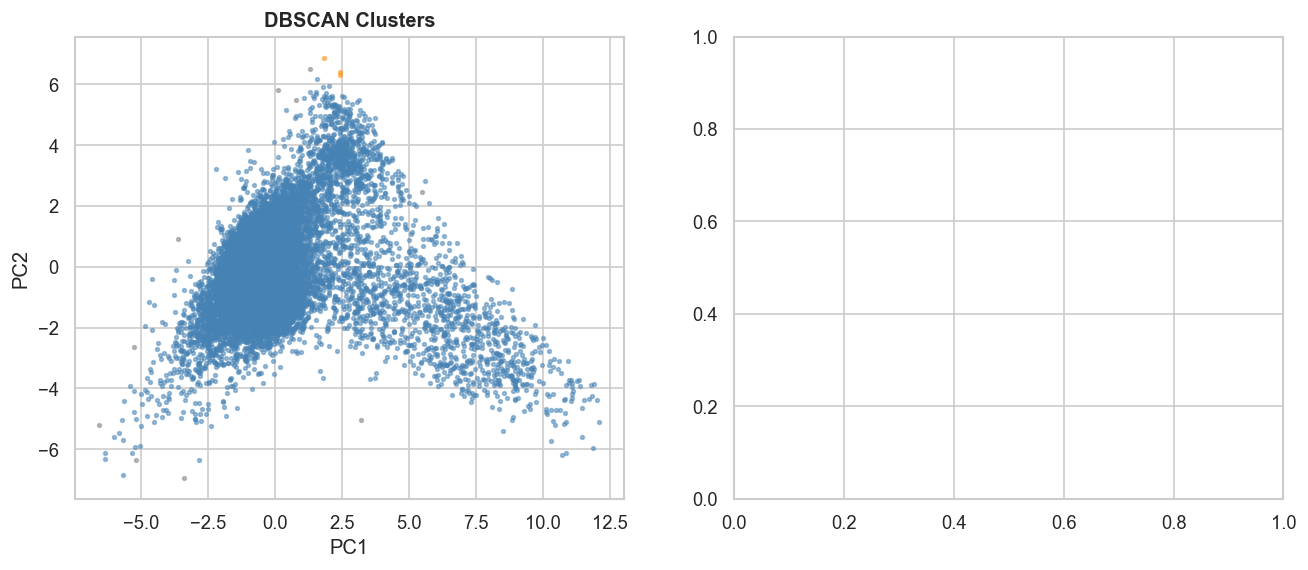

In [24]:
# SECTION 7.3.2: DBSCAN — Final Model

BEST_EPS  = 1.7
BEST_MS   = 3

dbscan    = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS)
labels_db = dbscan.fit_predict(X_scaled)

unique, counts = np.unique(labels_db, return_counts=True)
print("=" * 50)
print("DBSCAN FINAL MODEL RESULTS")
print("=" * 50)
for u, c in zip(unique, counts):
    label = "Noise" if u == -1 else f"Cluster {u}"
    print(f"{label}: {c} samples ({c/len(labels_db)*100:.1f}%)")

mask   = labels_db != -1
sil_db = silhouette_score(X_scaled[mask], labels_db[mask])
dbi_db = davies_bouldin_score(X_scaled[mask], labels_db[mask])
chi_db = calinski_harabasz_score(X_scaled[mask], labels_db[mask])
ari_db = adjusted_rand_score(y, labels_db)
nmi_db = normalized_mutual_info_score(y, labels_db)

print(f"\n--- Internal Metrics (excl. noise) ---")
print(f"Silhouette Score       : {sil_db:.4f}")
print(f"Davies-Bouldin Index   : {dbi_db:.4f}")
print(f"Calinski-Harabasz Index: {chi_db:.2f}")
print(f"\n--- External Metrics ---")
print(f"Adjusted Rand Index    : {ari_db:.4f}")
print(f"Normalized Mutual Info : {nmi_db:.4f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {-1: 'grey', 0: 'steelblue', 1: 'darkorange'}
for lbl, color in colors.items():
    mask_plot = labels_db == lbl
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    axes[0].scatter(X_pca2[mask_plot, 0],
                    X_pca2[mask_plot, 1],
                    c=color, s=5, alpha=0.5, label=name)
axes[0].set_title('DBSCAN Clusters', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0]

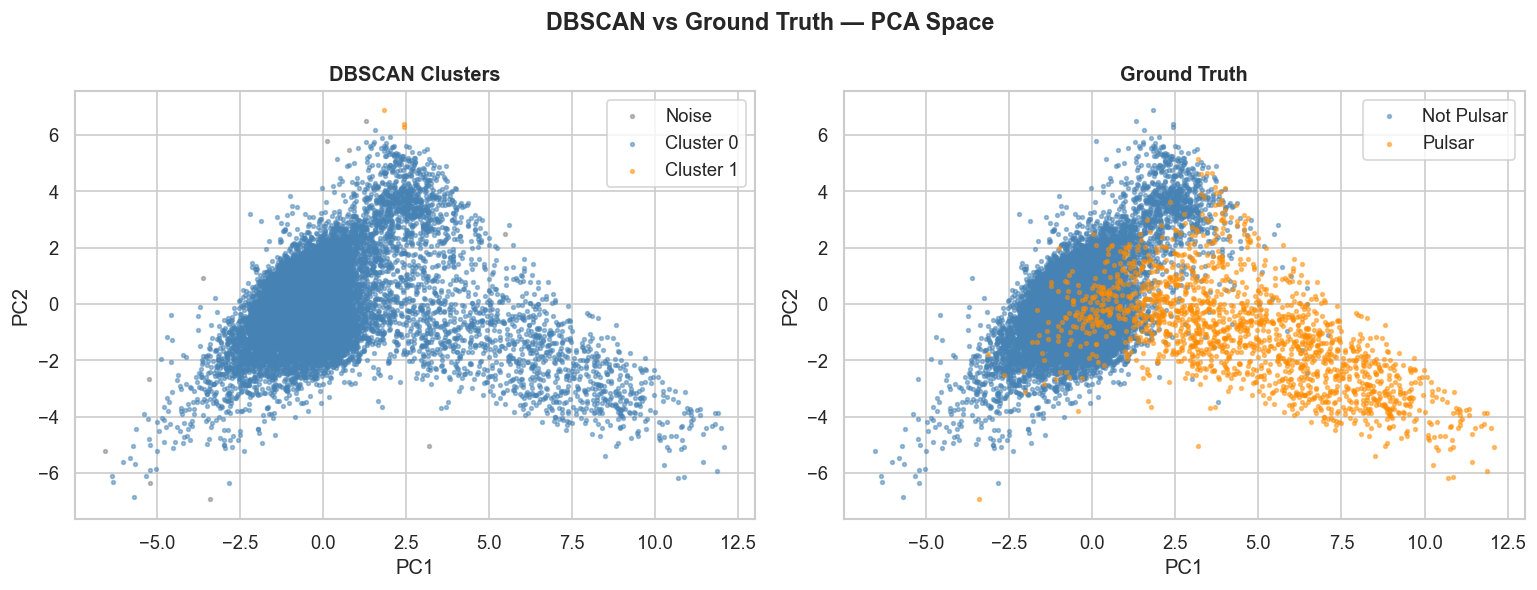

In [25]:
y_array = np.array(y)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {-1: 'grey', 0: 'steelblue', 1: 'darkorange'}
for lbl, color in colors.items():
    mask_plot = labels_db == lbl
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    axes[0].scatter(X_pca2[mask_plot, 0],
                    X_pca2[mask_plot, 1],
                    c=color, s=5, alpha=0.5, label=name)
axes[0].set_title('DBSCAN Clusters', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].scatter(X_pca2[y_array == 0, 0],
                X_pca2[y_array == 0, 1],
                c='steelblue', s=5, alpha=0.5, label='Not Pulsar')
axes[1].scatter(X_pca2[y_array == 1, 0],
                X_pca2[y_array == 1, 1],
                c='darkorange', s=5, alpha=0.5, label='Pulsar')
axes[1].set_title('Ground Truth', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('DBSCAN vs Ground Truth — PCA Space',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'dbscan_results.png'),
            bbox_inches='tight')
plt.show()

###  DBSCAN Final Model Results & Interpretation

**Cluster Distribution:**
| Label | Samples | Percentage |
|---|---|---|
| Cluster 0 | 17,884 | 99.9% |
| Cluster 1 | 3 | 0.0% |
| Noise | 11 | 0.1% |

**Internal Metrics:**
| Metric | Score | Interpretation |
|---|---|---|
| Silhouette Score | **0.6760** | High — but misleading (1 dominant cluster) |
| Davies-Bouldin Index | **0.3082** | Best of all 3 algorithms |
| Calinski-Harabasz Index | **35.42** | Very low — poor cluster density |

**External Metrics:**
| Metric | Score | Interpretation |
|---|---|---|
| Adjusted Rand Index | **0.0008** | Failed — no agreement with ground truth |
| Normalized Mutual Info | **0.0003** | Failed — no meaningful information captured |

**PCA Scatter Plot Observations:**
- DBSCAN (left) found essentially **1 massive cluster** containing
  99.9% of all data points — only 3 points in Cluster 1
- Comparing to Ground Truth (right) — DBSCAN completely 
  **failed to separate** Pulsar from Non-Pulsar candidates
- Only **11 noise points** detected — the dataset is too 
  uniformly dense for DBSCAN to find meaningful boundaries

**Why DBSCAN Failed on HTRU2:**
- HTRU2 has **uniform density*

##  Comparative Analysis

The following table summarises the performance of all three 
clustering algorithms across all evaluation metrics on the 
HTRU2 Pulsar dataset.

Metrics guide:
- **Silhouette Score** — higher is better (max = 1.0)
- **Davies-Bouldin Index** — lower is better (min = 0)
- **Calinski-Harabasz Index** — higher is better
- **Adjusted Rand Index** — higher is better (max = 1.0)
- **Normalized Mutual Info** — higher is better (max = 1.0)

ALGORITHM COMPARISON — ALL METRICS


,N Clusters,Silhouette,DBI,CHI,ARI,NMI
Algorithm,,,,,,
K-Means (k=2),2,0.601,1.0558,9891.65,0.6066,0.4051
Hierarchical (average),2,0.675,0.5347,8309.71,0.5203,0.4057
"DBSCAN (eps=1.7, ms=3)",2,0.676,0.3082,35.42,0.0008,0.0003


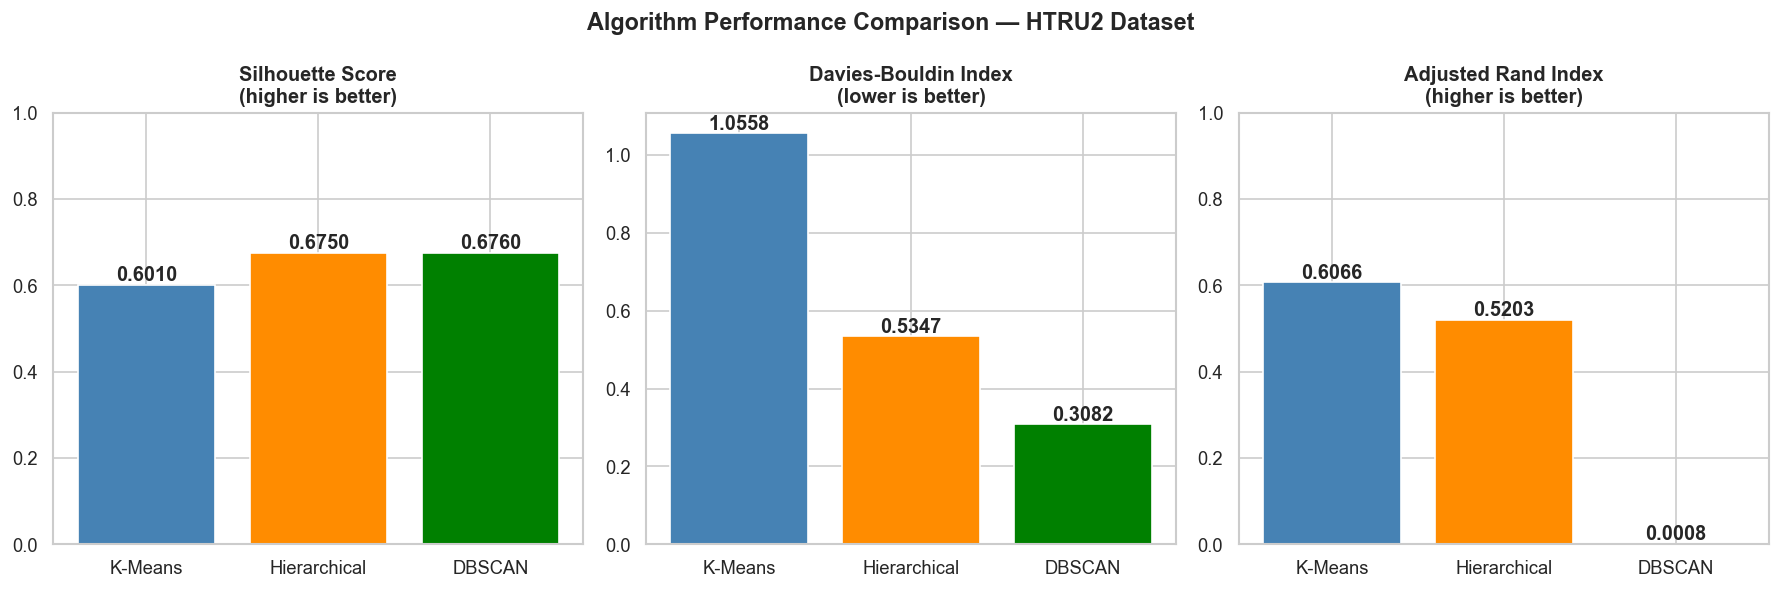

In [28]:
comparison = {
    'Algorithm': [
        'K-Means (k=2)',
        'Hierarchical (average)',
        'DBSCAN (eps=1.7, ms=3)'
    ],
    'N Clusters': [2, 2, 2],
    'Silhouette': [
        round(sil_km, 4),
        round(sil_hc, 4),
        round(sil_db, 4)
    ],
    'DBI': [
        round(dbi_km, 4),
        round(dbi_hc, 4),
        round(dbi_db, 4)
    ],
    'CHI': [
        round(chi_km, 2),
        round(chi_hc, 2),
        round(chi_db, 2)
    ],
    'ARI': [
        round(ari_km, 4),
        round(ari_hc, 4),
        round(ari_db, 4)
    ],
    'NMI': [
        round(nmi_km, 4),
        round(nmi_hc, 4),
        round(nmi_db, 4)
    ]
}

comp_df = pd.DataFrame(comparison).set_index('Algorithm')

print("=" * 65)
print("ALGORITHM COMPARISON — ALL METRICS")
print("=" * 65)
display(comp_df)

# ── Visual Comparison Bar Charts ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

algorithms = ['K-Means', 'Hierarchical', 'DBSCAN']
colors     = ['steelblue', 'darkorange', 'green']

# Silhouette
axes[0].bar(algorithms,
            [sil_km, sil_hc, sil_db],
            color=colors, edgecolor='white')
axes[0].set_title('Silhouette Score\n(higher is better)',
                  fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate([sil_km, sil_hc, sil_db]):
    axes[0].text(i, v + 0.01, f'{v:.4f}',
                 ha='center', fontweight='bold')

# DBI
axes[1].bar(algorithms,
            [dbi_km, dbi_hc, dbi_db],
            color=colors, edgecolor='white')
axes[1].set_title('Davies-Bouldin Index\n(lower is better)',
                  fontweight='bold')
for i, v in enumerate([dbi_km, dbi_hc, dbi_db]):
    axes[1].text(i, v + 0.01, f'{v:.4f}',
                 ha='center', fontweight='bold')

# ARI
axes[2].bar(algorithms,
            [ari_km, ari_hc, ari_db],
            color=colors, edgecolor='white')
axes[2].set_title('Adjusted Rand Index\n(higher is better)',
                  fontweight='bold')
axes[2].set_ylim(0, 1)
for i, v in enumerate([ari_km, ari_hc, ari_db]):
    axes[2].text(i, v + 0.01, f'{v:.4f}',
                 ha='center', fontweight='bold')

plt.suptitle('Algorithm Performance Comparison — HTRU2 Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'comparison.png'),
            bbox_inches='tight')
plt.show()


### parative Analysis Results & Interpretation

**Full Metrics Comparison:**

| Algorithm | Silhouette | DBI | CHI | ARI | NMI |
|---|---|---|---|---|---|
| K-Means (k=2) | 0.6010 | 1.0558 | **9,891.65** | **0.6066** | 0.4051 |
| Hierarchical (average) | 0.6750 | 0.5347 | 8,309.71 | 0.5203 | **0.4057** |
| DBSCAN (eps=1.7, ms=3) | **0.6760** | **0.3082** | 35.42 | 0.0008 | 0.0003 |

**Winner per Metric:**
| Metric | Winner | Reason |
|---|---|---|
| Silhouette | DBSCAN (0.6760) | Most compact single cluster |
| DBI | DBSCAN (0.3082) | Lowest inter-cluster overlap |
| CHI | K-Means (9,891.65) | Densest well-defined clusters |
| ARI | K-Means (0.6066) | Best match with ground truth |
| NMI | Hierarchical (0.4057) | Best information overlap |

**Key Findings:**

**K-Means** is the best overall algorithm for HTRU2 because:
- Highest ARI (0.6066) — best recovery of true class labels
- Highest CHI (9,891.65) — most compact and dense clusters
- Both elbow and silhouette agree on k=2 — matches true structure
- Cluster sizes (88.5% / 11.5%) closely match true split (90.8% / 9.2%)

**Hierarchical** performs well internally but:
- Best Silhouette (0.6750) and DBI (0.5347) among real algorithms
- Underestimates minority class — only found 683 pulsars vs 1,639 true
- Average linkage worked better than Ward and Complete on this dataset

**DBSCAN** is misleading on this dataset because:
- High Silhouette and low DBI are due to 1 dominant cluster — not meaningful
- ARI of 0.0008 confirms it completely failed to recover true structure
- HTRU2 has uniform density — DBSCAN requires density gaps to work

**Overall Recommendation:**
K-Means is the most suitable algorithm for the HTRU2 dataset
due to its globular cluster structure and clear 2-class separation.

##  Conclusion & Future Work

###  Summary of Findings

This project applied three unsupervised clustering algorithms 
to the HTRU2 Pulsar dataset containing 17,898 candidates 
described by 8 continuous features.

**Key findings:**
- **Preprocessing:** StandardScaler was critical due to 
  100x difference in feature scales across the 8 features
- **PCA:** Reduced 8 dimensions to 2 PCs capturing 78.48% 
  of total variance — enabling clean cluster visualisations
- **K-Means** performed best overall with ARI=0.6066 and 
  CHI=9,891.65 — successfully recovering the true class structure
- **Hierarchical** produced the tightest internal clusters 
  (Silhouette=0.6750, DBI=0.5347) but underestimated 
  the minority pulsar class
- **DBSCAN** failed on this dataset due to uniform density — 
  ARI=0.0008 confirms no meaningful separation was found

###  Limitations
- HTRU2 has significant **class imbalance (90.8% / 9.2%)** 
  which affects all clustering algorithms
- DBSCAN is fundamentally **unsuitable** for uniformly 
  dense datasets like HTRU2
- Hierarchical clustering is **computationally expensive** 
  on 17,898 samples — took significantly longer than K-Means
- PCA loses **21.52% of variance** when reducing to 2 components

###  Future Work
- Apply **ensemble clustering** — combine K-Means and 
  Hierarchical to improve minority class detection
- Try **Gaussian Mixture Models (GMM)** — handles overlapping 
  clusters and imbalanced data better than K-Means
- Use **different distance metrics** (Manhattan, Cosine) 
  in Hierarchical clustering
- Apply **UMAP** instead of PCA for non-linear dimensionality 
  reduction and visualisation
- Explore **resampling techniques** (SMOTE) before clustering 
  to address class imbalance